In [93]:
import mediapy as media
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Polygon
import cv2
from PIL import Image

In [83]:
def blend_frames(frame1, frame2, alpha=0.5):
    # Ensure both frames have the same shape
    assert frame1.shape == frame2.shape, "Frames must be the same shape to blend"
    # Blend the frames: (1 - alpha) * frame1 + alpha * frame2
    blended = (1 - alpha) * frame1 + alpha * frame2
    return blended.astype(np.uint8)

In [94]:
raw_data_path = "../youtube"

In [103]:
video_name = "qh-yxk-qAOc-1"

## Draw the arrows
when you run the next cell, you have an interactive interface to select the points on the images. play with opacity (alpha) if you can't find start or end point.

after you finished, run further cell to save your data.

In [104]:
frame1 = np.array(Image.open(
    Path(raw_data_path)
    / Path(video_name)
    / Path(f"{video_name}_frame1.png")
))
frame2 = np.array(Image.open(
    Path(raw_data_path)
    / Path(video_name)
    / Path(f"{video_name}_frame2.png")
))
blended_frame = blend_frames(frame1, frame2, alpha=0.5)

12

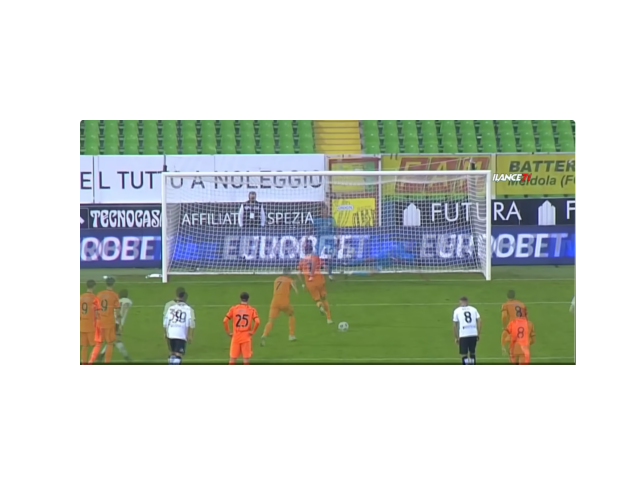

In [105]:
%matplotlib ipympl
user_points = []

blended_frame = blend_frames(frame1, frame2, alpha=0.5)
fig, ax = plt.subplots(1, 1)
ax.imshow(blended_frame)
ax.axis("off")
plt.draw()

def mouse_event(event):
    y, x = event.ydata, event.xdata
    radius = 10
    color = "gray"
    circ = plt.Circle((x, y), radius, facecolor=color, color=color)
    ax.add_patch(circ)
    if len(user_points) % 2 == 1:
        arrow = FancyArrowPatch(user_points[-1], (x, y),
                            arrowstyle='->', color='red', mutation_scale=20, linewidth=2)
        ax.add_patch(arrow)
    user_points.append((x, y))

fig.canvas.mpl_connect('button_press_event', mouse_event)

In [106]:
tracks_file = f"tracks_{video_name}.npy"
assert (
    user_points and len(user_points) % 2 == 0
), "Every source point must have a target point"
user_arr = np.array(user_points)
source_arr, target_arr = user_arr[0::2, :], user_arr[1::2, :]
tracks = np.stack([source_arr, target_arr])[None, ...]
np.save(Path(raw_data_path) / Path(video_name) / Path(tracks_file), tracks)

## Draw the mask

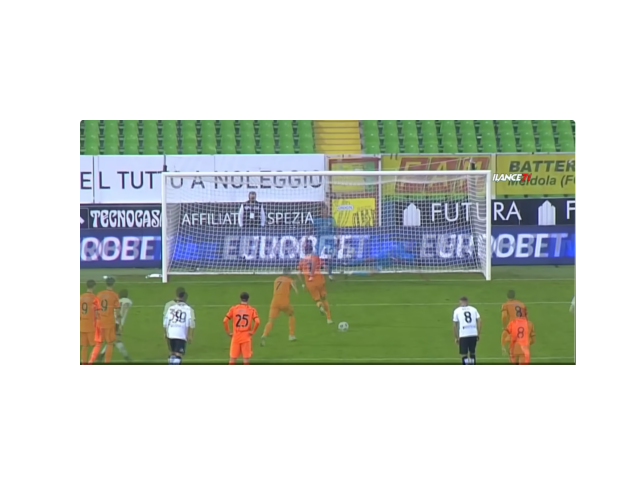

In [107]:
%matplotlib ipympl
mask_points = []

fig, ax = plt.subplots(1, 1)
ax.imshow(blended_frame)
ax.axis("off")
plt.draw()

def mask_event(event):
    if event.inaxes:
        x, y = event.xdata, event.ydata
        mask_points.append((x, y))
        circ = plt.Circle((x, y), radius=5, facecolor='blue', edgecolor='blue')
        ax.add_patch(circ)
        plt.draw()
        
        if len(mask_points) == 4:
            polygon = Polygon(mask_points, closed=True, fill=True, edgecolor='blue', facecolor='blue', alpha=0.3)
            ax.add_patch(polygon)
            plt.draw()
            fig.canvas.mpl_disconnect(cid)

cid = fig.canvas.mpl_connect('button_press_event', mask_event)


In [108]:
mask_file = f"mask_{video_name}.npy"
assert mask_points and len(mask_points) == 4, "draw a polygon with 4 points"

# Create a mask with the same dimensions as the faded_frame
mask = np.zeros_like(blended_frame, dtype=np.uint8)

# Create a polygon mask
polygon = np.array(mask_points, dtype=np.int32)
cv2.fillPoly(mask, [polygon], (255, 255, 255))

# Save the mask as a numpy array
np.save(Path(raw_data_path) / Path(video_name) / Path(mask_file), mask)

## Compress whole sample into a gif

In [9]:
mask_file = f"mask_{video_name}.npy"
mask = np.load(Path(raw_data_path) / Path(video_name) / Path(mask_file))

In [20]:
tracks_file = f"tracks_{video_name}.npy"
tracks = np.load(Path(raw_data_path) / Path(video_name) / Path(tracks_file))

First Frame,Edit Frame,Last Frame

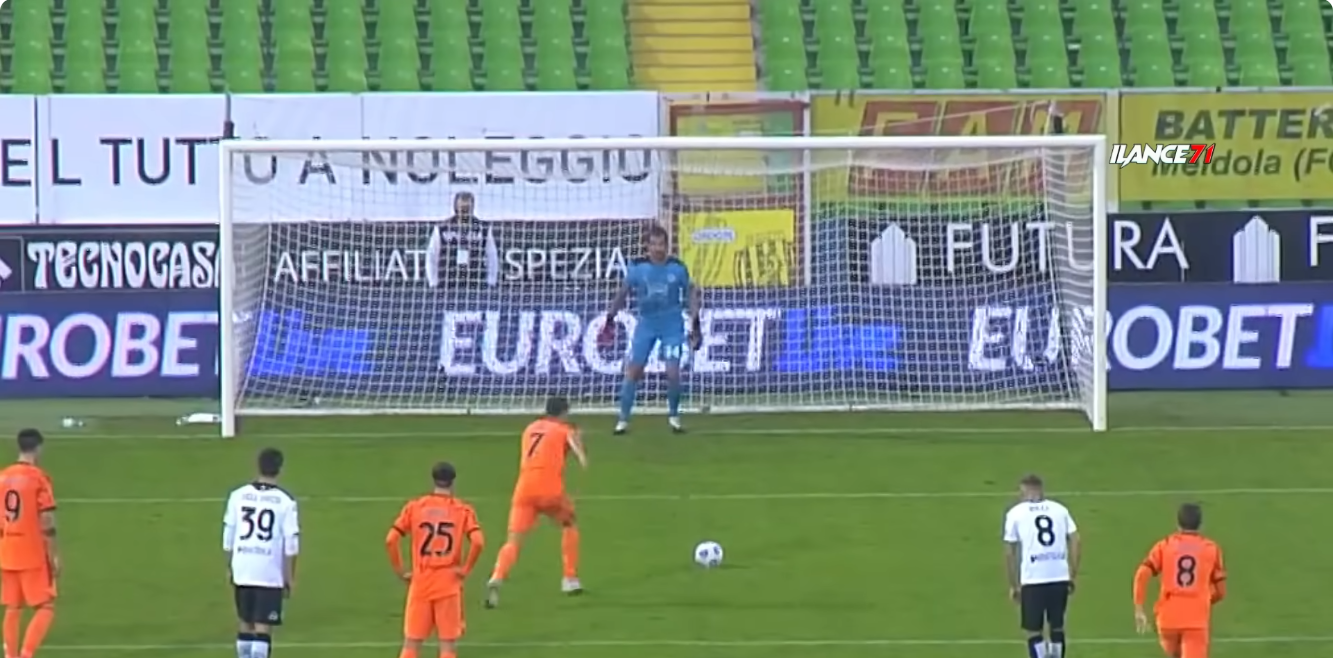
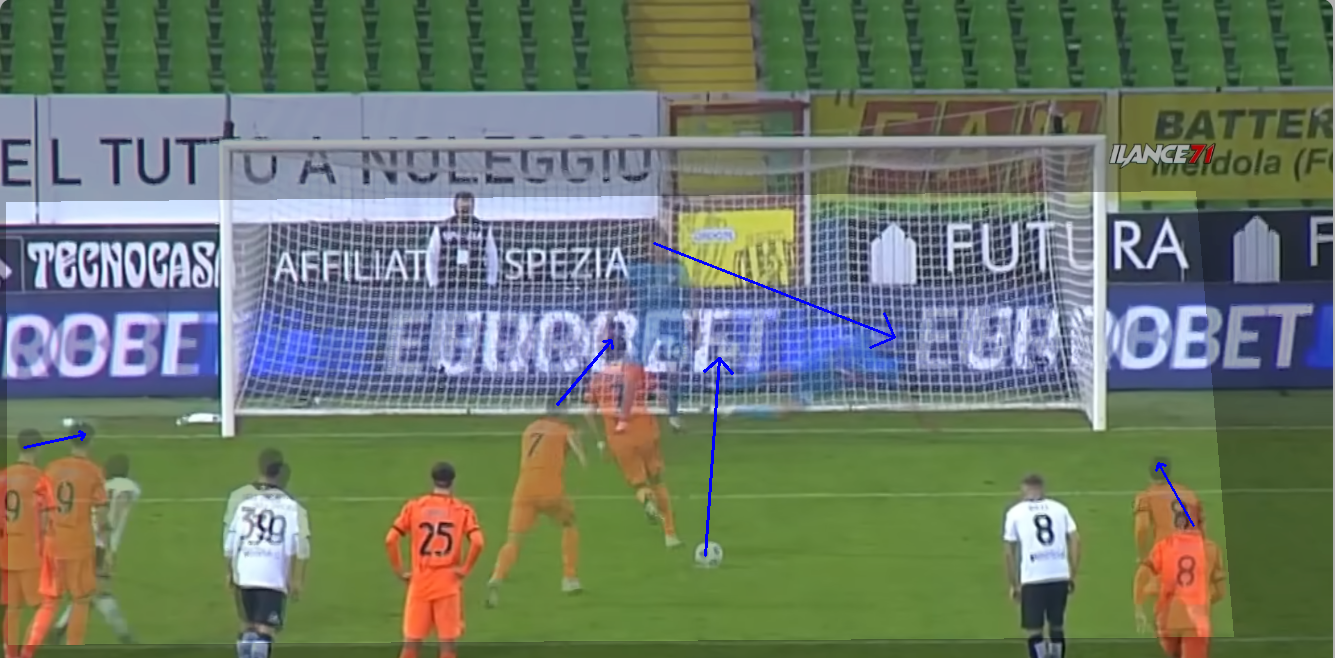
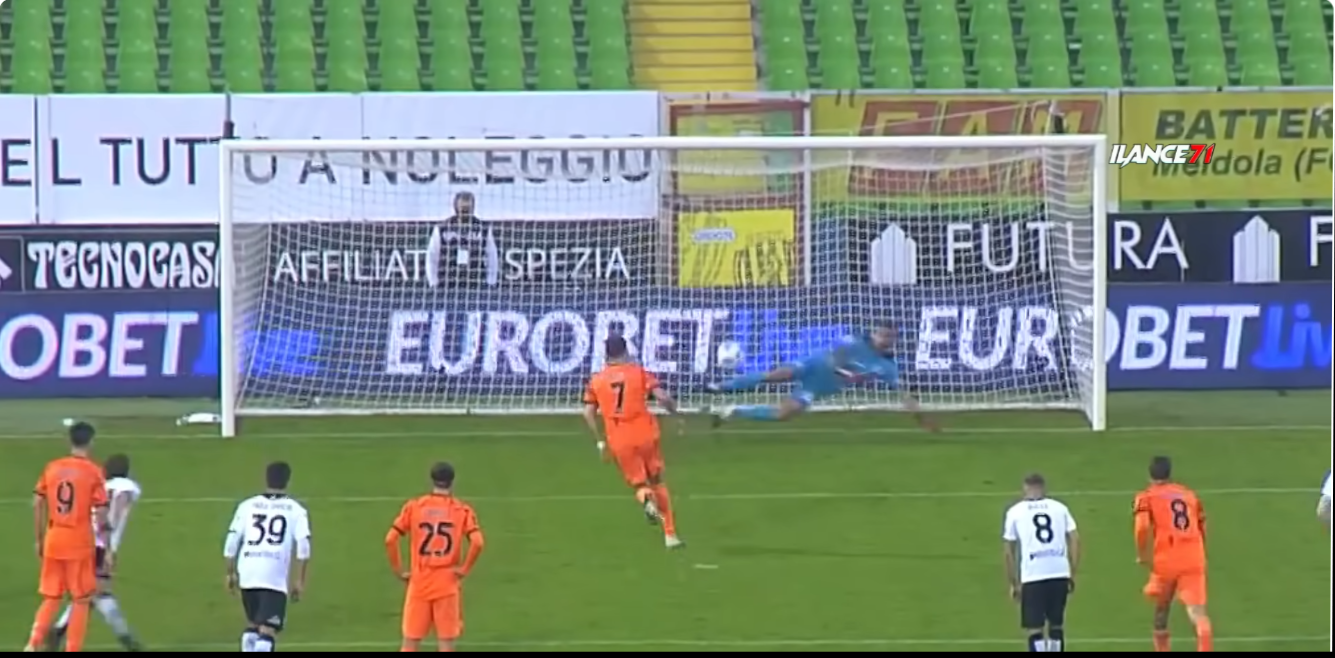

In [109]:
# create a copy of first frame; fade the copy with alpha=0.3 and draw the arrows and the mask on it and save it to edit_frame
# then create a gif from first_frame, edit_frame and last_frame. also write the caption on the top of the gif
edit_frame = (frame1 * 0.7).astype(np.uint8)
edit_frame[mask == 255] = blended_frame[mask == 255]
height, width = edit_frame.shape[:2]
for i in range(tracks.shape[2]):
    pt1 = tuple(map(int, tracks[0, 0, i]))
    pt2 = tuple(map(int, tracks[0, 1, i]))
    if 0 <= pt1[0] < width and 0 <= pt1[1] < height and 0 <= pt2[0] < width and 0 <= pt2[1] < height:
        cv2.arrowedLine(edit_frame, pt1, pt2, (0, 0, 255), 2)
    else:
        print(f"Skipping arrow from {pt1} to {pt2} as it is out of bounds")

media.show_images(
    [frame1, edit_frame, frame2], titles=["First Frame", "Edit Frame", "Last Frame"]
)

In [110]:
frames = [frame1, edit_frame, frame2]
# media.show_video(frames, title=caption, fps=1, codec="gif")
media.write_video(
    Path(raw_data_path) / Path(video_name) / Path(f"{video_name}.gif"),
    frames,
    fps=1,
    codec="gif",
)